In [5]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [4]:
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input
import numpy as np

# 머신러닝/딥러닝 : 데이터의 법칙성을 추출
- 다양한 분야에서 응용 : 글씨 인식, 문장 분류, 질병 진단, 얼굴 인식.
** ML/DL의 종류
- 지도학습(독립=입력변수와 종속=타겟=출력변수가 모두 주어졌을 경우)
    회귀분석(타겟변수가 연속형일 때) vs 분류분석(multi, binary)
- 비지도학습(입력변수만)
    군집분석(clustering ; 군집화)
- 강화학습

** 지도학습에서의 ML, DL 프로그래밍 방식
1. 데이터 셋 확보(input입력변수, output종속변수)
    원본 데이터 및 시뮬레이션을 통해 데이터 생성
2. 전처리
    스케일 조정
    훈련 데이터 + 시험 데이터 + 검증 데이터 = 6:2:2 / 7:2:1 등
    학습 및 평가 가능한 포맷으로 변환(2차원 numpy, DataFrame)
3. 모델 구성
    model = Sequential() 객체 생성 후 필요한 층을 add()함수로 Dense 추가
4. 모델 학습 과정 설정 
    compile() 함수 이용, loss손실함수, optimizer, metrics평가지표 설정 => 평가지표 종류 많으나 당분간 acc(정확도)만 사용
5. 모델 학습(학습 과정 확인하기)
    model.fit(input, output, epoch) - 훈련셋입력=독립변수, 훈련셋타겟=종속변수, epoch=학습회수, 검증셋
6. 모델 평가
    테스트(시험) 데이터셋을 인자로 넣은 evaluate()함수 이용, 그래프
7. 모델 사용
    model.predict() 이용. 입력데이터는 2차원
8. 모델 저장
    save()함수 이용해서 저장. 저장된 모델은 load_model()함수를 이용해서 불러올 수 있음

# 1. 데이터셋 생성
# 2. 데이터 전처리

In [33]:
# 학습데이터 = 훈련 데이터
x_train = np.array([1,2,3,4,5,6,7,8,9]*10) 
y_train = np.array([2,4,6,8,10,12,14,16,18]*10) # 그룹 10종
# 검증데이터
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,4,6,8,10,12,14,16,18])
# 시험데이터 = 테스트셋
x_test = np.array([1,2,3,4,5,6,7,8,9])
y_test = np.array([2,4,6,8,10,12,14,16,18])
x_train.shape, x_val.shape, x_test.shape,y_train.shape, y_val.shape, y_test.shape,

((90,), (9,), (9,), (90,), (9,), (9,))

In [34]:
# 인코딩 종류
data = np.array(['a','b','c','d'])
print('원 데이터 :',data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(data)
# labeled_data = le.transform(data)
labeled_data = le.fit_transform(data)
print('라벨인코딩된 데이터 :',labeled_data)
one_hot_encoded_data = to_categorical(labeled_data)
print('원핫인코딩 된 데이터 :',one_hot_encoded_data)

원 데이터 : ['a' 'b' 'c' 'd']
라벨인코딩된 데이터 : [0 1 2 3]
원핫인코딩 된 데이터 : [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [35]:
# 분류분석을 하기 위해 target을 원핫인코딩(라벨링전환)
data = np.array([1,2,2,4,2])
print(data)
categorical_one_hot = to_categorical(data)
print('to_categorical을 이용한 원핫인코딩 :\n',categorical_one_hot)
import pandas as pd
get_dumies_one_hot = pd.get_dummies(data)
display('get_dummies를 이용한 원핫인코딩 :',get_dumies_one_hot)
print(type(categorical_one_hot))
print(type(get_dumies_one_hot))

[1 2 2 4 2]
to_categorical을 이용한 원핫인코딩 :
 [[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]


'get_dummies를 이용한 원핫인코딩 :'

,1,2,4
0,1,0,0
1,0,1,0
2,0,1,0
3,0,0,1
4,0,1,0


<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


In [38]:
# 분류분석을 위한 target변수 라벨링 전환 ( = 원핫인코딩 )
Y_train = to_categorical(y_train,19)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)

In [40]:
print('훈련셋 :',x_train.shape, Y_train.shape) # 독립변수 1개, 타겟변수 19개 입력 하나에 출력 19개, 타겟변수값의 총합은 1
print('검증셋 :',x_val.shape, Y_val.shape)
print('시험셋 :',x_test.shape, Y_test.shape)

훈련셋 : (90,) (90, 19)
검증셋 : (9,) (9, 19)
시험셋 : (9,) (9, 19)


# 3. 모델 구성하기

In [45]:
# 3. 모델 구성
model = Sequential()
model.add(Input(shape=(1,))) # 입력층
model.add(Dense(units=38, activation='sigmoid' ))  # units 출력수, activation 활성화 함수 : relu, tanh... 등
# 교안50p, 은닉층에서 값을 세분하게 나눴다가 합치는 게 맞출 확률이 높아짐
model.add(Dense(units=64, activation='elu' ))
model.add(Dense(units=32, activation='elu' ))
model.add(Dense(units=19, activation = 'softmax'))
# softmax : 모든 출력 결과의 합이 1. 분류분석 마지막 layer(출력층)에서 activation으로 사용

In [46]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 38)                76        
                                                                 
 dense_5 (Dense)             (None, 64)                2496      
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dense_7 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습과정 설정

In [47]:
model.compile(loss = 'categorical_crossentropy', # 분류분석에서 사용하는 손실함수(원핫인코딩 실시 후)
              optimizer = 'sgd', # sgd, gd, rmsprop, adam, nag ... => adam이랑 sgd 추천
              metrics=['accuracy']) # 평가지표 : accuracy 신뢰도

# 5. 모델 학습 시키기

In [50]:
hist = model.fit(x_train, Y_train, 
                 epochs=300, # 학습 회수 : 300번
                 batch_size = 10, # batch_size : 학습에 사용할 데이터의 규모 : 10개를 한번에 확인하고 가중치를 조정하겠다.
                 verbose=2, # 학습결과 출력 옵션 : 0 -> 출력없음, 1 -> 기본값, 2 -> epoch별 로그 메세지를 상세출력
                 validation_data = (x_val, Y_val)
                )

Epoch 1/300
9/9 - 1s - loss: 3.1945 - accuracy: 0.0000e+00 - val_loss: 3.0704 - val_accuracy: 0.0000e+00 - 794ms/epoch - 88ms/step
Epoch 2/300
9/9 - 0s - loss: 3.0133 - accuracy: 0.0000e+00 - val_loss: 2.9263 - val_accuracy: 0.1111 - 52ms/epoch - 6ms/step
Epoch 3/300
9/9 - 0s - loss: 2.8906 - accuracy: 0.1111 - val_loss: 2.8216 - val_accuracy: 0.1111 - 45ms/epoch - 5ms/step
Epoch 4/300
9/9 - 0s - loss: 2.7909 - accuracy: 0.1111 - val_loss: 2.7387 - val_accuracy: 0.1111 - 47ms/epoch - 5ms/step
Epoch 5/300
9/9 - 0s - loss: 2.7204 - accuracy: 0.1111 - val_loss: 2.6709 - val_accuracy: 0.1111 - 45ms/epoch - 5ms/step
Epoch 6/300
9/9 - 0s - loss: 2.6549 - accuracy: 0.1111 - val_loss: 2.6123 - val_accuracy: 0.1111 - 46ms/epoch - 5ms/step
Epoch 7/300
9/9 - 0s - loss: 2.5998 - accuracy: 0.1111 - val_loss: 2.5610 - val_accuracy: 0.1111 - 46ms/epoch - 5ms/step
Epoch 8/300
9/9 - 0s - loss: 2.5579 - accuracy: 0.1111 - val_loss: 2.5149 - val_accuracy: 0.1111 - 45ms/epoch - 5ms/step
Epoch 9/300
9/9 - 

Epoch 69/300
9/9 - 0s - loss: 1.6621 - accuracy: 0.4111 - val_loss: 1.6349 - val_accuracy: 0.5556 - 43ms/epoch - 5ms/step
Epoch 70/300
9/9 - 0s - loss: 1.6513 - accuracy: 0.4000 - val_loss: 1.6235 - val_accuracy: 0.3333 - 45ms/epoch - 5ms/step
Epoch 71/300
9/9 - 0s - loss: 1.6419 - accuracy: 0.3111 - val_loss: 1.6117 - val_accuracy: 0.4444 - 43ms/epoch - 5ms/step
Epoch 72/300
9/9 - 0s - loss: 1.6291 - accuracy: 0.3222 - val_loss: 1.6032 - val_accuracy: 0.5556 - 41ms/epoch - 5ms/step
Epoch 73/300
9/9 - 0s - loss: 1.6139 - accuracy: 0.3556 - val_loss: 1.5901 - val_accuracy: 0.4444 - 47ms/epoch - 5ms/step
Epoch 74/300
9/9 - 0s - loss: 1.6081 - accuracy: 0.4000 - val_loss: 1.5791 - val_accuracy: 0.6667 - 44ms/epoch - 5ms/step
Epoch 75/300
9/9 - 0s - loss: 1.6072 - accuracy: 0.3889 - val_loss: 1.5697 - val_accuracy: 0.5556 - 46ms/epoch - 5ms/step
Epoch 76/300
9/9 - 0s - loss: 1.6003 - accuracy: 0.4000 - val_loss: 1.5592 - val_accuracy: 0.4444 - 43ms/epoch - 5ms/step
Epoch 77/300
9/9 - 0s - 

Epoch 136/300
9/9 - 0s - loss: 1.1147 - accuracy: 0.7444 - val_loss: 1.0881 - val_accuracy: 0.7778 - 45ms/epoch - 5ms/step
Epoch 137/300
9/9 - 0s - loss: 1.1171 - accuracy: 0.7444 - val_loss: 1.0802 - val_accuracy: 0.7778 - 44ms/epoch - 5ms/step
Epoch 138/300
9/9 - 0s - loss: 1.1096 - accuracy: 0.7333 - val_loss: 1.0743 - val_accuracy: 0.7778 - 39ms/epoch - 4ms/step
Epoch 139/300
9/9 - 0s - loss: 1.0989 - accuracy: 0.7778 - val_loss: 1.0682 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 140/300
9/9 - 0s - loss: 1.1027 - accuracy: 0.7111 - val_loss: 1.0653 - val_accuracy: 0.7778 - 42ms/epoch - 5ms/step
Epoch 141/300
9/9 - 0s - loss: 1.0793 - accuracy: 0.8111 - val_loss: 1.0557 - val_accuracy: 0.8889 - 40ms/epoch - 4ms/step
Epoch 142/300
9/9 - 0s - loss: 1.0833 - accuracy: 0.7889 - val_loss: 1.0507 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 143/300
9/9 - 0s - loss: 1.0909 - accuracy: 0.8111 - val_loss: 1.0502 - val_accuracy: 0.7778 - 44ms/epoch - 5ms/step
Epoch 144/300
9/

Epoch 203/300
9/9 - 0s - loss: 0.8087 - accuracy: 0.9000 - val_loss: 0.7695 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 204/300
9/9 - 0s - loss: 0.8030 - accuracy: 0.9111 - val_loss: 0.7637 - val_accuracy: 0.8889 - 42ms/epoch - 5ms/step
Epoch 205/300
9/9 - 0s - loss: 0.7906 - accuracy: 0.9000 - val_loss: 0.7642 - val_accuracy: 0.8889 - 45ms/epoch - 5ms/step
Epoch 206/300
9/9 - 0s - loss: 0.8003 - accuracy: 0.8222 - val_loss: 0.7512 - val_accuracy: 1.0000 - 45ms/epoch - 5ms/step
Epoch 207/300
9/9 - 0s - loss: 0.7895 - accuracy: 0.9111 - val_loss: 0.7626 - val_accuracy: 0.7778 - 40ms/epoch - 4ms/step
Epoch 208/300
9/9 - 0s - loss: 0.7792 - accuracy: 0.9000 - val_loss: 0.7448 - val_accuracy: 1.0000 - 47ms/epoch - 5ms/step
Epoch 209/300
9/9 - 0s - loss: 0.7784 - accuracy: 0.9000 - val_loss: 0.7438 - val_accuracy: 1.0000 - 48ms/epoch - 5ms/step
Epoch 210/300
9/9 - 0s - loss: 0.7784 - accuracy: 0.9111 - val_loss: 0.7364 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 211/300
9/

Epoch 270/300
9/9 - 0s - loss: 0.5905 - accuracy: 0.8778 - val_loss: 0.5390 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 271/300
9/9 - 0s - loss: 0.5735 - accuracy: 0.9667 - val_loss: 0.5350 - val_accuracy: 1.0000 - 45ms/epoch - 5ms/step
Epoch 272/300
9/9 - 0s - loss: 0.5720 - accuracy: 0.9333 - val_loss: 0.5400 - val_accuracy: 0.8889 - 44ms/epoch - 5ms/step
Epoch 273/300
9/9 - 0s - loss: 0.5694 - accuracy: 0.9111 - val_loss: 0.5558 - val_accuracy: 0.7778 - 41ms/epoch - 5ms/step
Epoch 274/300
9/9 - 0s - loss: 0.5751 - accuracy: 0.9222 - val_loss: 0.5462 - val_accuracy: 1.0000 - 42ms/epoch - 5ms/step
Epoch 275/300
9/9 - 0s - loss: 0.5736 - accuracy: 0.9444 - val_loss: 0.5267 - val_accuracy: 1.0000 - 46ms/epoch - 5ms/step
Epoch 276/300
9/9 - 0s - loss: 0.5654 - accuracy: 0.9222 - val_loss: 0.5330 - val_accuracy: 0.8889 - 45ms/epoch - 5ms/step
Epoch 277/300
9/9 - 0s - loss: 0.5441 - accuracy: 0.9222 - val_loss: 0.5352 - val_accuracy: 0.8889 - 44ms/epoch - 5ms/step
Epoch 278/300
9/

In [51]:
hist.history.keys() # trainset => 'loss', 'accuracy', val_set => 'val_loss', 'val_accuracy'

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

# 6. 모델 평가하기(모델 학습과정 살펴보고, evaluate)

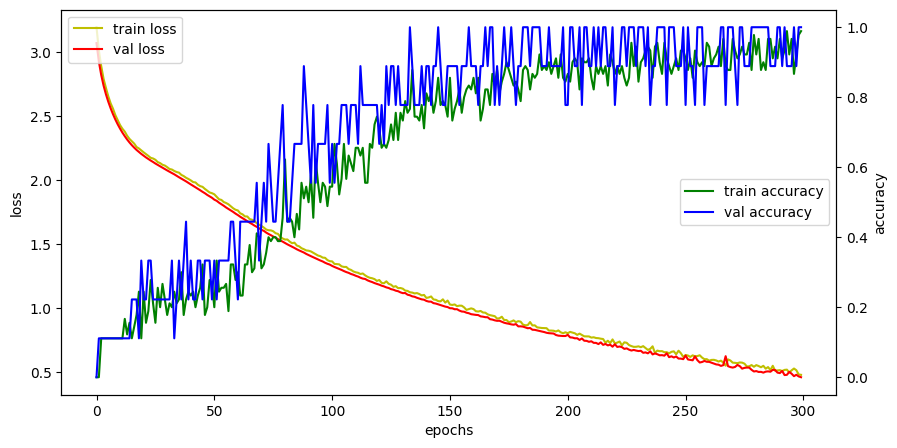

In [73]:
# 모델 학습과정 시각화
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history.get('loss'), label = 'train loss', color='y')
loss_ax.plot(hist.history.get('val_loss'), label = 'val loss', color='r')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')

acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history.get('accuracy'), label = 'train accuracy', color='g')
acc_ax.plot(hist.history.get('val_accuracy'), label = 'val accuracy', color='b')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc = 'upper left')
acc_ax.legend(loc = 'center right')

In [76]:
# 모델 평가하기
score = model.evaluate(x_test,Y_test, batch_size=1, verbose=2)

9/9 - 0s - loss: 0.4597 - accuracy: 1.0000 - 30ms/epoch - 3ms/step


In [77]:
score # loss, accuracy

[0.4596917927265167, 1.0]

In [80]:
print('평가된 loss :', score[0])
print('평가된 accuracy :', score[1]*100,'%')

평가된 loss : 0.4596917927265167
평가된 accuracy : 100.0 %


# 7. 모델 사용하기

In [87]:
H = model.predict(np.array([[2]]))
H

1/1 [==============================] - 0s 30ms/step
[3.63981206e-11 5.01664474e-11 1.02416575e-01 4.16899761e-12
 7.72703826e-01 2.36851364e-13 1.23714104e-01 4.30451404e-11
 1.16387568e-03 2.53993004e-09 1.64927587e-06 5.67102843e-13
 3.06580233e-10 3.46776411e-15 7.17615258e-14 2.10059032e-12
 4.62314677e-18 1.60931185e-10 4.66401388e-25]


In [90]:
# 분류분석의 예측은 predict결과를 argmax함수를 사용해서 활용
model.predict(np.array([[2]])).argmax()

1/1 [==============================] - 0s 34ms/step


4

In [92]:
# 4를 몇 % 확률로 예측했는지
H[0, H.argmax()] * 100

77.27038264274597

# 8. 모델 저장하기

In [94]:
# model.save('model/02_deep.h5')
from tensorflow.keras.models import save_model
save_model(model,'model/02_deep.h5')

## 저장된 모델 사용하기

In [95]:
from tensorflow.keras.models import load_model
model2 = load_model('model/02_deep.h5')

In [97]:
H2 = model2.predict([[4]])
H2.argmax()

1/1 [==============================] - 0s 45ms/step


8

In [98]:
H2[0,H2.argmax()]

0.63767123